# YouTube Data Preprocessing and Analysis

The purpose of this notebook is to conduct a comprehensive analysis of data for the six selected YouTube channels that was pulled in `extraction.ipynb`.

By gathering and analyzing data from these channels, the project aims to uncover valuable insights into video performance, audience engagement, and content strategies. Specifically, we will delve into various aspects such as subscriber growth, view counts, likes, comments, and video characteristics to gain a deeper understanding of what resonates with viewers and drives success on these channels. For instance, we will explore whether certain types of content or video formats perform better in terms of engagement metrics. Our analysis will seek to provide customized recommendations and actionable insights for these content creators to enhance their channel's performance and audience satisfaction.

## `channel_stats.csv` Data Definitions

Aggregated metrics by channel

channelName: Name of the YouTube channel

subscribers: Total # of Subscribers

views: Total # of views that the channel has accumulated

totalVideos: Total # of videos that the channel has uploaded

playlistId: ID to the playlist of all the channel's videos

## `videos.csv` Data Definitions

videoId: Unique ID string of a YouTube video

channelTitle: Title of the YouTube channel

videoTitle: The title of a YouTube video

description: A short summary about the video

tags: Keywords accompanied by a hashtag that are embedded in the video caption/description

publishedAt: Date in which the video was published

viewCount: Number of views that a video has at the time of extraction

likeCount: Number of likes a the video received at the time of extraction

commentCount: Number of comments that a video received

duration: Minutes and seconds of the video in ISO 8601 format

definition: Video quality: either high definition (hd) or standard definition (sd)

caption: Boolean field that depicts whether or not the video has a caption



## Imports

In [210]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import isodate
import ast
import re
import shap
from textblob import TextBlob
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

In [211]:
video_df = pd.read_csv("../data/processed/videos.csv")

In [212]:
video_df.head()

,videoId,channelTitle,videoTitle,description,tags,publishedAt,viewCount,likeCount,commentCount,duration,definition,caption,pulled_at
0,8kDXMS-CcBQ,Hoop Intellect,Channel Update!| Hired by an NBA Team?,Thank you. \n☘️☘️☘️\n\nTwitter: https://www.tw...,"['Hoop Intellect', 'NBA Draft']",2025-08-20T22:51:56Z,14219,2126,449,PT2M35S,hd,False,2026-07-11 10:45:34.357667
1,Yjd0l236Nd8,Hoop Intellect,2025 NBA Draft 2nd Round Recap | Steals?,"Covering the 2nd round, some of the best value...","['Hoop Intellect', 'NBA Draft', 'NBA Draft 2nd...",2025-06-28T13:30:36Z,11849,588,36,PT15M8S,hd,False,2026-07-11 10:45:34.357667
2,dUkHfLzUctc,Hoop Intellect,2025 NBA Draft First Round Recap!,Recapping the entire first round of the 2025 N...,"['Hoop Intellect', 'NBA Draft', '2025 NBA Draf...",2025-06-26T21:40:24Z,22044,1023,77,PT19M39S,hd,False,2026-07-11 10:45:34.357667
3,MqPClagBKuw,Hoop Intellect,2025 NBA Draft Big Board 7.0 | Final!,Final board of the year! Appreciate the suppor...,"['Hoop Intellect', 'NBA Draft']",2025-06-25T02:56:56Z,33250,1159,107,PT35M25S,hd,False,2026-07-11 10:45:34.357667
4,ni4UyMk8UUw,Hoop Intellect,Walter Clayton Jr. Scouting Report | 2025 NBA ...,Twitter: https://www.twitter.com/HoopIntelllec...,"['Hoop Intellect', 'NBA Draft', 'Walter Clayto...",2025-06-21T15:28:20Z,16407,452,97,PT15M57S,hd,False,2026-07-11 10:45:34.357667


# Data Preprocessing

In [213]:
video_df.isnull().sum()

videoId         0
channelTitle    0
videoTitle      0
description     5
tags            8
publishedAt     0
viewCount       0
likeCount       0
commentCount    0
duration        0
definition      0
caption         0
pulled_at       0
dtype: int64

In [214]:
video_df[video_df['likeCount'].isnull() | video_df['commentCount'].isnull()]

,videoId,channelTitle,videoTitle,description,tags,publishedAt,viewCount,likeCount,commentCount,duration,definition,caption,pulled_at


In [215]:
video_df.drop(video_df[video_df['likeCount'].isnull() | video_df['commentCount'].isnull()].index, inplace=True)

In [216]:
video_df.dtypes

videoId           str
channelTitle      str
videoTitle        str
description       str
tags              str
publishedAt       str
viewCount       int64
likeCount       int64
commentCount    int64
duration          str
definition        str
caption          bool
pulled_at         str
dtype: object

### Applying Transformations to Numeric Fields

In [217]:
numeric_cols = ["viewCount", "likeCount", "commentCount"]
video_df[numeric_cols] = video_df[numeric_cols].apply(pd.to_numeric, errors="coerce", axis=1)

### Creating **Publish Date** and **Time of Day** Fields

This is to allow analysis on whether the week a video is published and/or the time of day matters in terms of performance

In [218]:
video_df["publishedAt"] = pd.to_datetime(video_df["publishedAt"])
video_df['publishedAt'] = video_df['publishedAt'].dt.tz_convert('America/New_York') # Standardizing timezone of publishedAt to EST
video_df["publishDay"] = video_df["publishedAt"].dt.strftime("%A")

In [219]:
video_df.head()

,videoId,channelTitle,videoTitle,description,tags,publishedAt,viewCount,likeCount,commentCount,duration,definition,caption,pulled_at,publishDay
0,8kDXMS-CcBQ,Hoop Intellect,Channel Update!| Hired by an NBA Team?,Thank you. \n☘️☘️☘️\n\nTwitter: https://www.tw...,"['Hoop Intellect', 'NBA Draft']",2025-08-20 18:51:56-04:00,14219,2126,449,PT2M35S,hd,False,2026-07-11 10:45:34.357667,Wednesday
1,Yjd0l236Nd8,Hoop Intellect,2025 NBA Draft 2nd Round Recap | Steals?,"Covering the 2nd round, some of the best value...","['Hoop Intellect', 'NBA Draft', 'NBA Draft 2nd...",2025-06-28 09:30:36-04:00,11849,588,36,PT15M8S,hd,False,2026-07-11 10:45:34.357667,Saturday
2,dUkHfLzUctc,Hoop Intellect,2025 NBA Draft First Round Recap!,Recapping the entire first round of the 2025 N...,"['Hoop Intellect', 'NBA Draft', '2025 NBA Draf...",2025-06-26 17:40:24-04:00,22044,1023,77,PT19M39S,hd,False,2026-07-11 10:45:34.357667,Thursday
3,MqPClagBKuw,Hoop Intellect,2025 NBA Draft Big Board 7.0 | Final!,Final board of the year! Appreciate the suppor...,"['Hoop Intellect', 'NBA Draft']",2025-06-24 22:56:56-04:00,33250,1159,107,PT35M25S,hd,False,2026-07-11 10:45:34.357667,Tuesday
4,ni4UyMk8UUw,Hoop Intellect,Walter Clayton Jr. Scouting Report | 2025 NBA ...,Twitter: https://www.twitter.com/HoopIntelllec...,"['Hoop Intellect', 'NBA Draft', 'Walter Clayto...",2025-06-21 11:28:20-04:00,16407,452,97,PT15M57S,hd,False,2026-07-11 10:45:34.357667,Saturday


In [220]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"
video_df['timeOfDay'] = video_df['publishedAt'].dt.hour.apply(time_of_day)

### Transforming Current ISO 8601 `duration` Field into Decimal Minutes

In [221]:
video_df["durationSecs"] = video_df["duration"].apply(lambda x: isodate.parse_duration(x))
video_df["durationSecs"] = video_df["durationSecs"].dt.total_seconds()

In [222]:
video_df[["duration", "durationSecs"]]

,duration,durationSecs
0,PT2M35S,155.0
1,PT15M8S,908.0
2,PT19M39S,1179.0
3,PT35M25S,2125.0
4,PT15M57S,957.0
...,...,...
1840,PT13M13S,793.0
1841,PT9M42S,582.0
1842,PT11M34S,694.0
1843,PT10M33S,633.0


In [223]:
video_df["durationMins"] = round(video_df["durationSecs"] / 60, 1)
video_df = video_df.drop(columns = ['durationSecs', 'duration'])

### Creating Engagement Metric
This metric will be used to gauge video satisfaction and intrigue

In [224]:
video_df['engagementRate'] = (video_df['likeCount'] + video_df['commentCount']) / video_df['viewCount']

### Adding Number of Tags in Video

In [225]:
def count_tags(x):
    if pd.isna(x):
        return 0
    try:
        return len(ast.literal_eval(x))
    except (ValueError, SyntaxError):
        return 0

video_df["tagCount"] = video_df["tags"].apply(count_tags)


### Removing `caption` due to heavy imbalance of True and False values

In [226]:
video_df['caption'].value_counts()

caption
False    1838
True        7
Name: count, dtype: int64

In [227]:
video_df = video_df.drop(columns = ['caption'])

In [228]:
video_df.head()

,videoId,channelTitle,videoTitle,description,tags,publishedAt,viewCount,likeCount,commentCount,definition,pulled_at,publishDay,timeOfDay,durationMins,engagementRate,tagCount
0,8kDXMS-CcBQ,Hoop Intellect,Channel Update!| Hired by an NBA Team?,Thank you. \n☘️☘️☘️\n\nTwitter: https://www.tw...,"['Hoop Intellect', 'NBA Draft']",2025-08-20 18:51:56-04:00,14219,2126,449,hd,2026-07-11 10:45:34.357667,Wednesday,Evening,2.6,0.181096,2
1,Yjd0l236Nd8,Hoop Intellect,2025 NBA Draft 2nd Round Recap | Steals?,"Covering the 2nd round, some of the best value...","['Hoop Intellect', 'NBA Draft', 'NBA Draft 2nd...",2025-06-28 09:30:36-04:00,11849,588,36,hd,2026-07-11 10:45:34.357667,Saturday,Morning,15.1,0.052663,24
2,dUkHfLzUctc,Hoop Intellect,2025 NBA Draft First Round Recap!,Recapping the entire first round of the 2025 N...,"['Hoop Intellect', 'NBA Draft', '2025 NBA Draf...",2025-06-26 17:40:24-04:00,22044,1023,77,hd,2026-07-11 10:45:34.357667,Thursday,Evening,19.6,0.049900,26
3,MqPClagBKuw,Hoop Intellect,2025 NBA Draft Big Board 7.0 | Final!,Final board of the year! Appreciate the suppor...,"['Hoop Intellect', 'NBA Draft']",2025-06-24 22:56:56-04:00,33250,1159,107,hd,2026-07-11 10:45:34.357667,Tuesday,Night,35.4,0.038075,2
4,ni4UyMk8UUw,Hoop Intellect,Walter Clayton Jr. Scouting Report | 2025 NBA ...,Twitter: https://www.twitter.com/HoopIntelllec...,"['Hoop Intellect', 'NBA Draft', 'Walter Clayto...",2025-06-21 11:28:20-04:00,16407,452,97,hd,2026-07-11 10:45:34.357667,Saturday,Morning,16.0,0.033461,20


# Exploratory Data Analysis

## Understanding the Distribution of Length of Videos and Checking for Outliers

/var/folders/78/xqhz8y514531stzkhdzzznsw0000gn/T/ipykernel_4688/2150891922.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(video_df["durationMins"], vert=False, patch_artist=True,


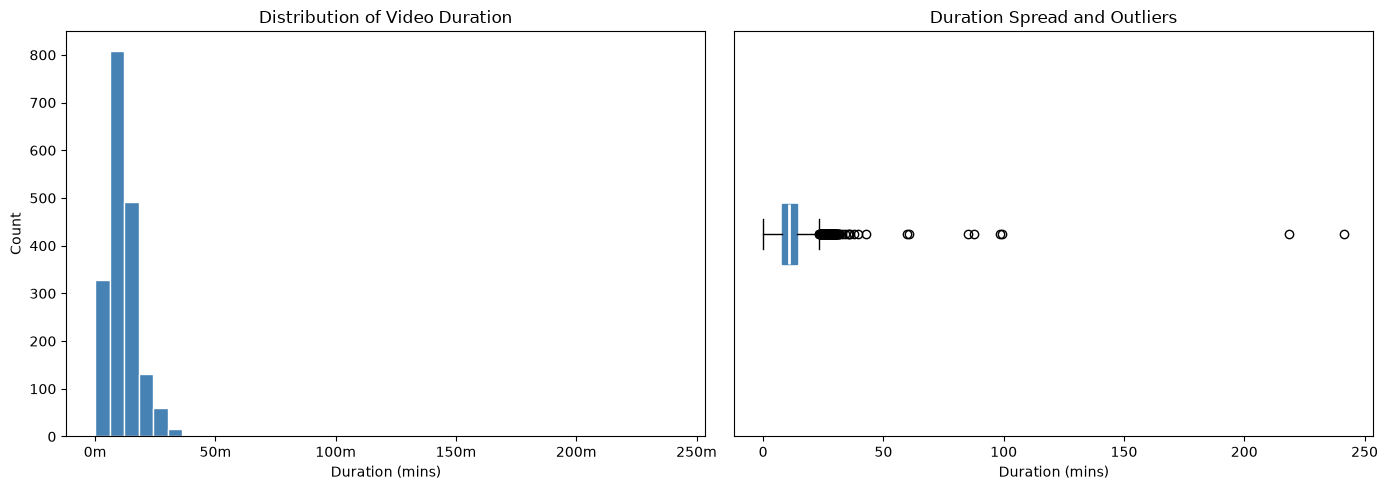

count    1845.0
mean       11.6
std        10.4
min         0.0
25%         7.8
50%        10.7
75%        14.0
max       241.5
Name: durationMins, dtype: float64
Videos over 60 mins: 7
Videos over 30 mins: 27


In [229]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(video_df["durationMins"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Video Duration")
axes[0].set_xlabel("Duration (mins)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}m"))

axes[1].boxplot(video_df["durationMins"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="steelblue"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_title("Duration Spread and Outliers")
axes[1].set_xlabel("Duration (mins)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(video_df["durationMins"].describe().round(1))
print(f"Videos over 60 mins: {(video_df['durationMins'] > 60).sum()}")
print(f"Videos over 30 mins: {(video_df['durationMins'] > 30).sum()}")

Most of the videos are 5-25 minutes long. There are some outliers with 27 videos over 30 minutes long and 7 over an hour. Let's look into those outliers and determine the difference in these types of videos in comparison to the rest.

In [230]:
video_df[video_df["durationMins"] >= 30][["channelTitle", "videoTitle", "durationMins", "publishedAt"]].sort_values("durationMins", ascending=False)

,channelTitle,videoTitle,durationMins,publishedAt
867,Thinking Football,NFL DRAFT DAY 1 LIVESTREAM,241.5,2023-04-28 00:15:39-04:00
907,Thinking Football,NFL DRAFT DAY 1 LIVESTREAM,218.8,2022-04-28 23:57:06-04:00
242,Hoop Intellect,Hoop Intellect Podcast Episode 1 | TTW Pierre ...,99.4,2021-05-05 13:42:42-04:00
210,Hoop Intellect,Hoop Intellect Podcast Episode 4 | Summer Leag...,98.6,2021-08-23 19:34:25-04:00
1325,Hoop Venue,The LaMelo Ball Trade Saga,87.8,2025-11-22 06:00:16-05:00
239,Hoop Intellect,Hoop Intellect Podcast Episode 2 | @NBADraftju...,85.0,2021-05-14 15:00:04-04:00
30,Hoop Intellect,Ace Bailey's Recent Play & Early 2026 Draft Ta...,60.7,2025-01-25 11:50:40-05:00
1814,Hoop Venue,Ranking the Top 25 Players in the NBA (2022),60.0,2022-08-30 21:34:59-04:00
1174,Daniel Li,Kings-Warriors Was A Series For the Ages,42.6,2023-09-07 11:00:46-04:00
1145,Daniel Li,How the Celtics Finally Won The Title,39.6,2024-07-06 11:11:44-04:00


The videos > 60 minutes are rare podcast episodes and livestreams. These videos are still fine for general analysis (per-channel aggregations and engagement investigations), but they do skew the data in regards to the video length investigation. We'll create a separate dataframe that excludes these. The rest of the videos in this query aren't as common as these creators' usual vidoes but do mirror their usual content (big boards, mock drafts, deep dives into players/teams).

In [231]:
duration_df = video_df[video_df['durationMins'] < 60].copy()

## Duration vs Performance

Creating 5 bins of ranges of video length (0-5, 5-10, 10-20, 20-30, 30+) and using them in four plots where the mean and median of each metric are calculated.

durationBin
0-5m      269
5-10m     545
10-20m    863
20-30m    140
30m+       20
Name: count, dtype: int64
  durationBin  viewCount_mean  viewCount_median  likeCount_mean  \
0        0-5m       127694.86           31055.0         2772.51   
1       5-10m       140705.50           68948.0         3487.22   
2      10-20m       137941.62           60393.0         3607.41   
3      20-30m       178593.84           53696.5         4476.01   
4        30m+       233499.00           35275.5         4653.15   

   likeCount_median  commentCount_mean  commentCount_median  \
0            1175.0             154.25                 44.0   
1            1657.0             311.34                183.0   
2            1615.0             346.81                201.0   
3            1543.0             561.13                211.5   
4            1216.0             433.65                166.5   

   engagementRate_mean  engagementRate_median  
0                 0.04                   0.04  
1             

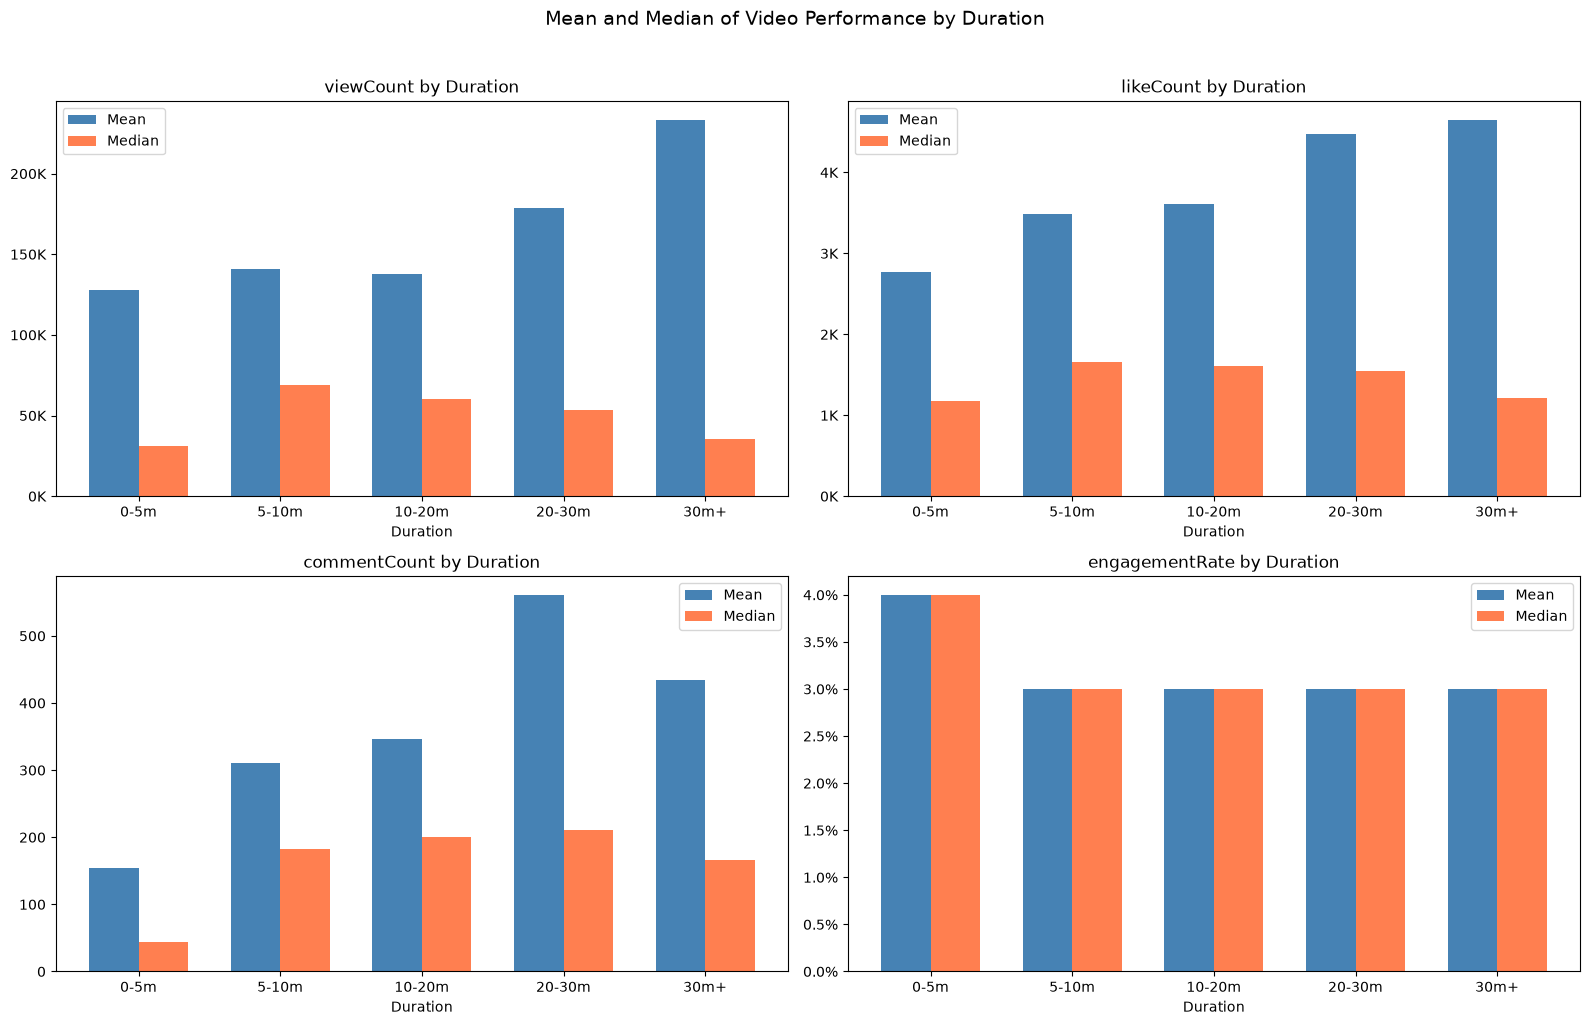

In [232]:
bins = [0, 5, 10, 20, 30, float("inf")]
labels = ["0-5m", "5-10m", "10-20m", '20-30m', '30m+']

duration_df['durationBin'] = pd.cut(duration_df['durationMins'], bins=bins, labels=labels, right=False)
metrics = ['viewCount', 'likeCount', 'commentCount', 'engagementRate']

agg_df = duration_df.groupby('durationBin', observed=True)[metrics].agg(['mean', 'median']).round(2)
agg_df.columns = ["_".join(col) for col in agg_df.columns]
agg_df = agg_df.reset_index()

print(duration_df['durationBin'].value_counts().sort_index())
print(agg_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    x = range(len(labels))
    width = 0.35

    bars_mean = ax.bar([p-width/2 for p in x], agg_df[f"{metric}_mean"], width=width, label="Mean", color="steelblue")
    bars_med = ax.bar([p+width/2 for p in x], agg_df[f"{metric}_median"], width=width, label="Median", color="coral")

    ax.set_title(f"{metric} by Duration")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_xlabel("Duration")
    ax.legend()

    if metric == "engagementRate":
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    elif metric == "commentCount":
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
        
plt.suptitle("Mean and Median of Video Performance by Duration", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- Median view counts peak at 5-10 and 10-20 minutes (~60k views each). 0-5 minute videos have the lowest median (~22k). 30+ has the second lowest (~35k)
- Engagement rate is around 3-4% across the board
- Longer videos (20+) attract more comments relative to their view count, suggesting
  a more invested, discussion-oriented audience
- The large gap between mean and median views across all bins reflects a small number of
  high-performing outliers in every length category; the median is the more reliable
  benchmark for typical video performance

## Video Upload Timing

I'm not expecting too much of variance between different upload times for these channels. The sample is relatively small (859), and these channels are more niche than an average YouTube channel as their videos are more suited for their organically built followers rather than a broader audience. Still, I think it would be interesting to learn more about each channel's upload habits and how it relates to the metrics.

In [233]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
times = ["Morning", "Afternoon", "Evening", "Night"]

video_df["publishDay"] = pd.Categorical(video_df["publishDay"], categories=days, ordered=True)
video_df["timeOfDay"] = pd.Categorical(video_df["timeOfDay"], categories=times, ordered=True)

day_agg = video_df.groupby('publishDay', observed=True)[["viewCount", "likeCount", "commentCount", "engagementRate"]].agg(['median']).round(2)
time_agg = video_df.groupby('timeOfDay', observed=True)[["viewCount", "likeCount", "commentCount", "engagementRate"]].agg(['median']).round(2)

day_agg.columns = ["_".join(col) for col in day_agg.columns]
day_agg = day_agg.reset_index()

time_agg.columns = ["_".join(col) for col in time_agg.columns]
time_agg = time_agg.reset_index()

print(video_df["publishDay"].value_counts().sort_index())
print()
print(video_df["timeOfDay"].value_counts().sort_index())

publishDay
Monday       245
Tuesday      244
Wednesday    275
Thursday     268
Friday       291
Saturday     329
Sunday       193
Name: count, dtype: int64

timeOfDay
Morning      234
Afternoon    596
Evening      615
Night        400
Name: count, dtype: int64


## Median Video Performance by Publish Timing (Day of Week and Time of Day)

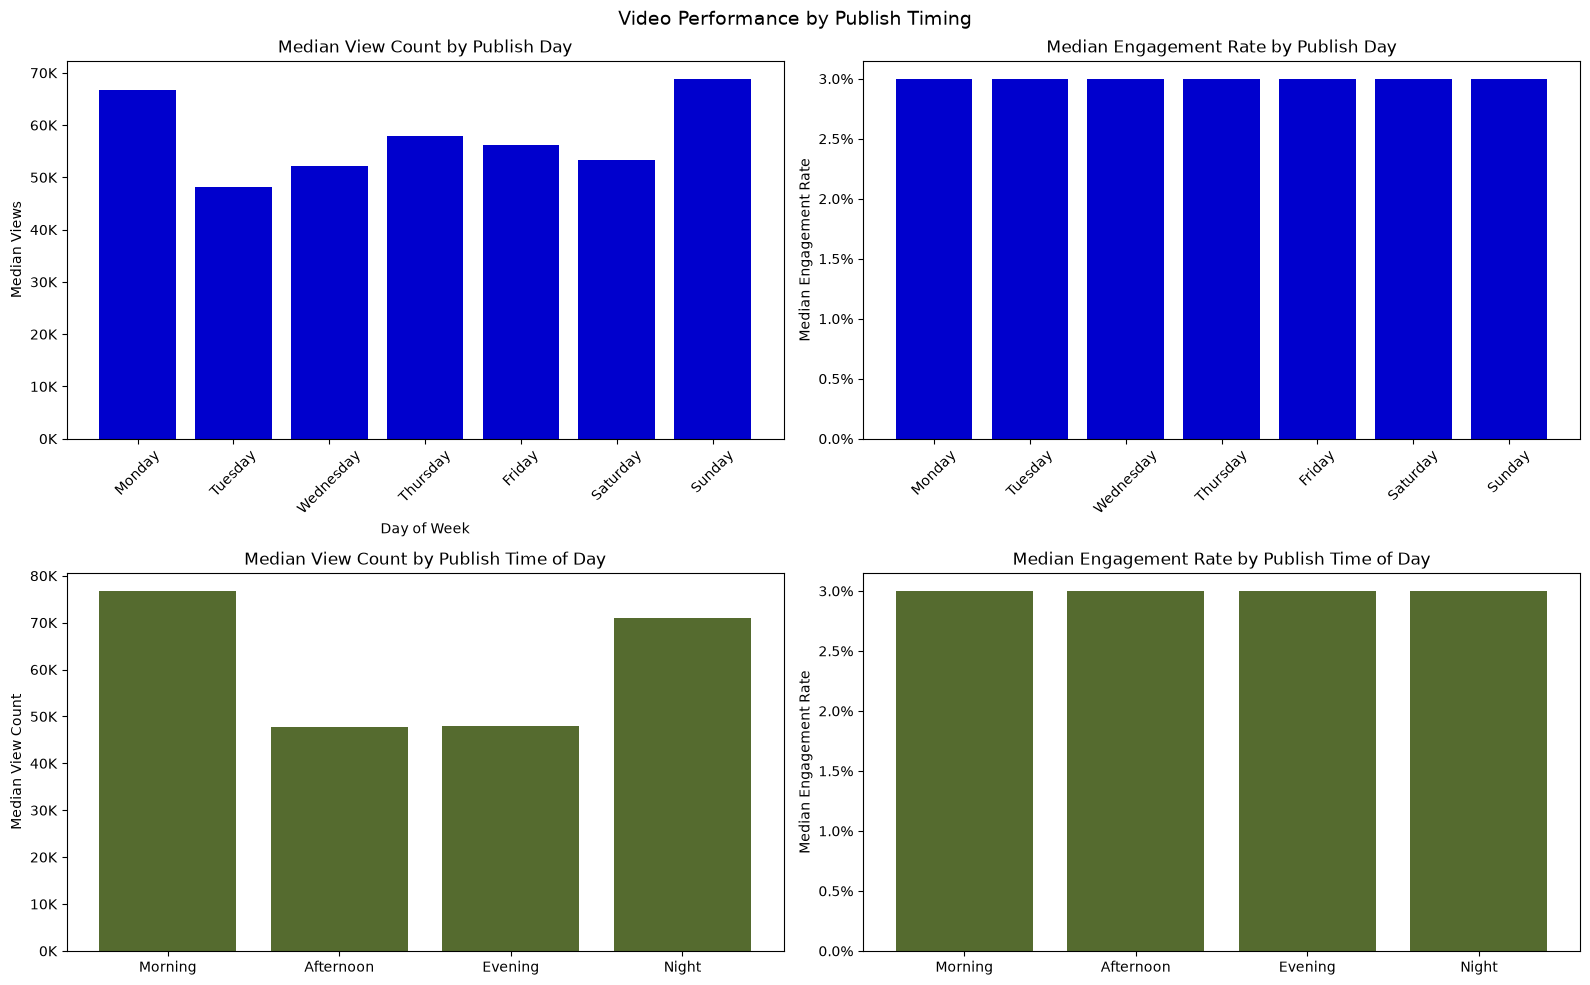

In [234]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(day_agg["publishDay"], day_agg["viewCount_median"], color="mediumblue")
axes[0, 0].set_title("Median View Count by Publish Day")
axes[0, 0].set_xlabel("Day of Week")
axes[0, 0].set_ylabel("Median Views")
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(day_agg["publishDay"], day_agg["engagementRate_median"], color="mediumblue")
axes[0, 1].set_title("Median Engagement Rate by Publish Day")
axes[0, 1].set_ylabel("Median Engagement Rate")
axes[0, 1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(time_agg["timeOfDay"], time_agg["viewCount_median"], color="darkolivegreen")
axes[1, 0].set_title("Median View Count by Publish Time of Day")
axes[1, 0].set_ylabel("Median View Count")
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

axes[1, 1].bar(time_agg["timeOfDay"], time_agg["engagementRate_median"], color="darkolivegreen")
axes[1, 1].set_title("Median Engagement Rate by Publish Time of Day")
axes[1, 1].set_ylabel("Median Engagement Rate")
axes[1, 1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))

plt.suptitle("Video Performance by Publish Timing", fontsize=14)
plt.tight_layout()
plt.show()

Engagement rate is not influenced by publishing patterns at all on average, but the views are. Sunday has the highest median views. Morning and Night uploads render the highest median views.

## Video Upload Time of Day X Day of Week Heatmap

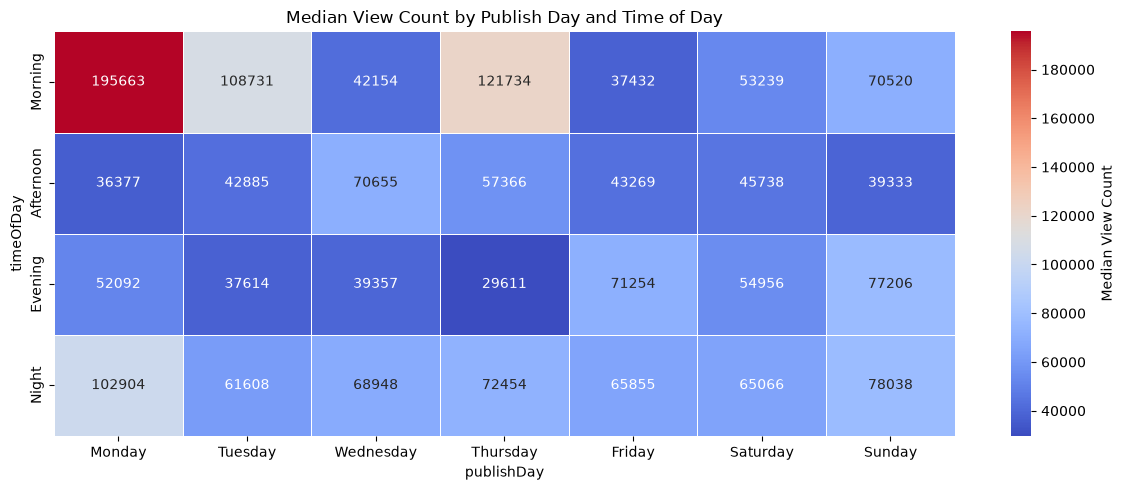

In [235]:
pivot = video_df.pivot_table(
    values="viewCount",
    index="timeOfDay",
    columns="publishDay",
    aggfunc="median",
    observed=True
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm",
            linewidths=0.5, cbar_kws={"label": "Median View Count"})
plt.title("Median View Count by Publish Day and Time of Day")
plt.tight_layout()
plt.show()

Morning uploads on Monday (~146k) and Thursday (~1221k) yield highest median views. Evening and Afternoon uploads are consistently in the blue.

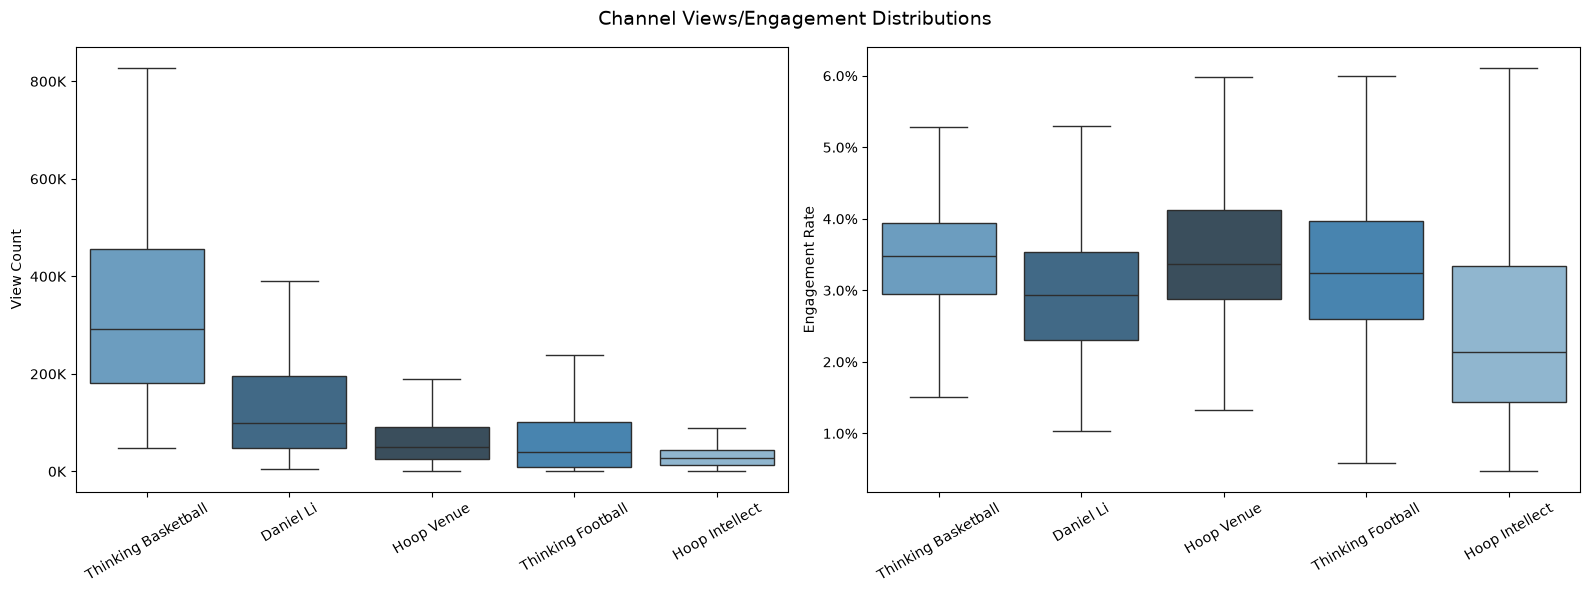

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

channel_order = (video_df.groupby('channelTitle')["viewCount"].median().sort_values(ascending=False).index.tolist())


sns.boxplot(data=video_df, x="channelTitle", y="viewCount", hue="channelTitle", order=channel_order, legend=False, ax=axes[0], palette="Blues_d", showfliers=False)
axes[0].set_xlabel("")
axes[0].set_ylabel("View Count")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=video_df, x="channelTitle", y="engagementRate", hue="channelTitle", order=channel_order, legend=False, ax=axes[1], palette="Blues_d", showfliers=False)
axes[1].set_xlabel("")
axes[1].set_ylabel("Engagement Rate")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Channel Views/Engagement Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [237]:
channel_summary = video_df.groupby("channelTitle").agg(
    videoCount=("videoId", "count"),
    medianViews=("viewCount", "median"),
    meanViews=("viewCount", "mean"),
    medianEngagement=("engagementRate", "median"),
    meanEngagement=("engagementRate", "mean"),
    medianLikes=("likeCount", "median"),
    medianComments=("commentCount", "median")
)

channel_summary = channel_summary.sort_values("medianViews", ascending=False)
print(channel_summary.to_string())

                     videoCount  medianViews      meanViews  medianEngagement  meanEngagement  medianLikes  medianComments
channelTitle                                                                                                              
Thinking Basketball         310     291189.0  391164.661290          0.034784        0.034367       9683.0           667.0
Daniel Li                   264      99880.0  198302.977273          0.029285        0.029731       2496.0           208.0
Hoop Venue                  589      49261.0   72957.137521          0.033715        0.036131       1554.0           160.0
Thinking Football           258      39747.5  104330.806202          0.032405        0.033810       1335.0           128.0
Hoop Intellect              424      28232.5   38452.915094          0.021397        0.025445        526.5            98.5


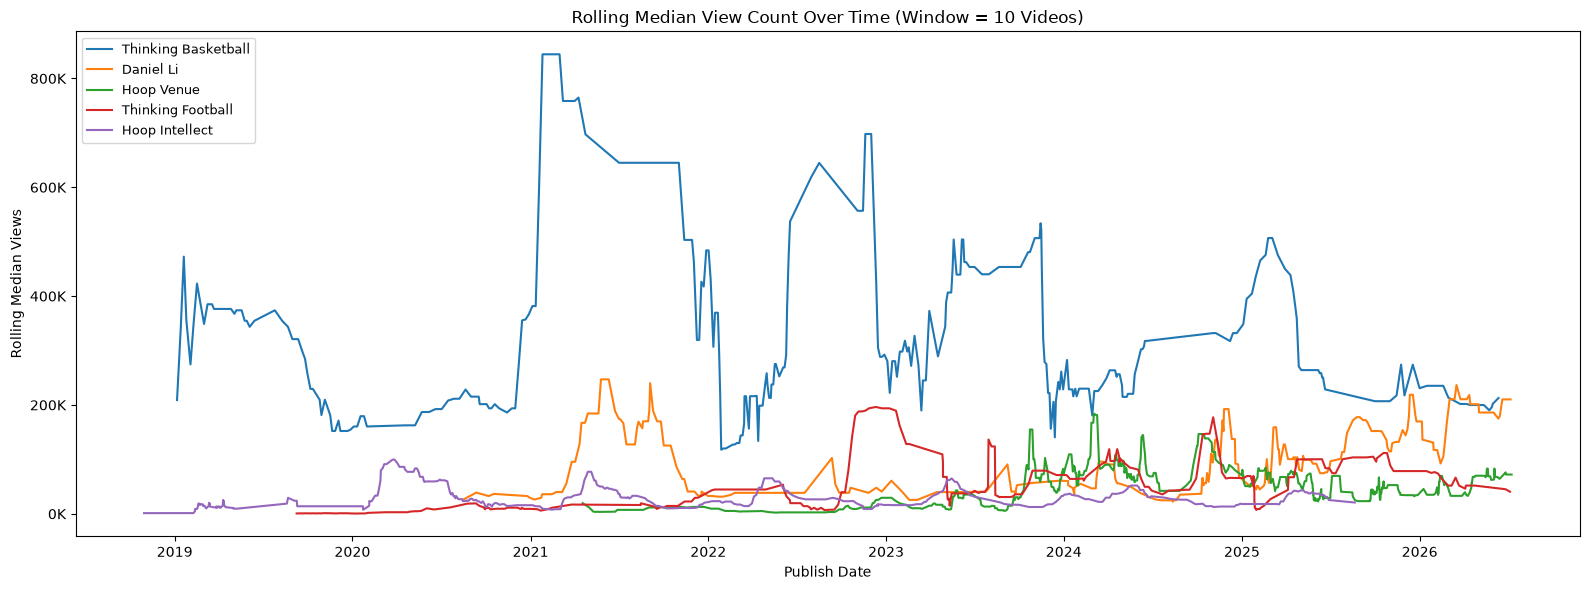

In [238]:
video_df_sorted = video_df.sort_values('publishedAt')
fig, ax = plt.subplots(figsize=(16, 6))

for channel in channel_order:
    channel_data = video_df_sorted[video_df_sorted["channelTitle"] == channel].copy()
    channel_data = channel_data.set_index("publishedAt")["viewCount"]
    rolling = channel_data.rolling(10, min_periods=3).median()
    ax.plot(rolling.index, rolling.values, label=channel, linewidth=1.5)

ax.set_title("Rolling Median View Count Over Time (Window = 10 Videos)")
ax.set_xlabel("Publish Date")
ax.set_ylabel("Rolling Median Views")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Per-Channel Performance Comparison

*Hoop Intellect has not uploaded a video since August 2025 due to being hired by the Boston Celtics (https://www.youtube.com/watch?v=8kDXMS-CcBQ&pp=ygUOaG9vcCBpbnRlbGxlY3Q%3D)

### View Count Tiers
Channels separate into three distinct tiers by median view count:
- **Tier 1 — Thinking Basketball** (291K): Operates at a scale roughly 3x larger
  than the next closest channel. Wide IQR reflects both a consistently high floor
  and significant viral outliers
- **Tier 2 — Daniel Li** (96K): Clear separation from the field, with a mean
  nearly 2x the median indicating a small number of breakout videos
- **Tier 3 — Hoop Venue, Thinking Football, Hoop Intellect** (21K–48K):
  Clustered in reach but meaningfully different in engagement behavior

### Engagement Rate
Engagement rate rankings diverge from view count rankings, indicating reach and
audience investment operate independently:
- Thinking Basketball (3.5%) and Hoop Venue (3.4%) lead on engagement despite
  sitting at opposite ends of the view count spectrum
- Hoop Intellect (2.1%) is the notable underperformer — lower reach and lower
  proportional audience investment than peers
- Daniel Li (3.0%) is the most balanced channel across both dimensions

### Channel Trajectories
- Thinking Basketball shows two distinct peaks — early 2019 (Raptors championship, analytical explanations/theory,
  and the ending of the Golden State Warriors dynansty) and mid-2021 (post-COVID NBA resurgence)
- Daniel Li and Thinking Football show active growth arcs through 2025–2026
- Hoop Venue and Hoop Intellect show high variability

In [239]:
top_videos = (
    video_df.sort_values("viewCount", ascending=False)
    .groupby("channelTitle")
    .head(3)
    [["channelTitle", "videoTitle", "viewCount", "likeCount", "commentCount", "engagementRate", "publishedAt"]]
    .sort_values(["channelTitle", "viewCount"], ascending=[True, False])
)

top_videos["viewCount"] = top_videos["viewCount"].apply(lambda x: f"{x:,.0f}")
top_videos["likeCount"] = top_videos["likeCount"].apply(lambda x: f"{x:,.0f}")
top_videos["commentCount"] = top_videos["commentCount"].apply(lambda x: f"{x:,.0f}")
top_videos["engagementRate"] = top_videos["engagementRate"].apply(lambda x: f"{x*100:.2f}%")

top_videos

,channelTitle,videoTitle,viewCount,likeCount,commentCount,engagementRate,publishedAt
1214,Daniel Li,You Didn't Notice This When Jeremy Lin Waved O...,"5,028,084","67,050","2,818",1.39%,2021-09-03 14:10:19-04:00
1194,Daniel Li,Explaining the LeBron James and Austin Reaves ...,"1,851,748","18,404","1,044",1.05%,2022-01-30 18:22:08-05:00
1155,Daniel Li,D'Angelo Russell Creates His Own Play For The ...,"1,655,510","17,421",872,1.10%,2024-03-12 23:02:31-04:00
386,Hoop Intellect,Alex Caruso 2018-19 Season Highlights [HD],"716,427","5,018",924,0.83%,2019-04-10 12:13:11-04:00
363,Hoop Intellect,Alex Caruso 2019-20 Season Highlights | Part 1,"514,438","4,585",333,0.96%,2020-01-20 18:25:42-05:00
338,Hoop Intellect,Lonzo Ball 2019-20 Season Highlights,"485,882","5,018",487,1.13%,2020-04-24 17:38:34-04:00
1537,Hoop Venue,These Are Not The Same Lakers,"600,746","11,460","1,018",2.08%,2024-10-14 21:12:31-04:00
1702,Hoop Venue,Why Luka Doncic is Impossible to Guard,"560,167","7,344",517,1.40%,2023-10-10 16:30:06-04:00
1689,Hoop Venue,When the #1 Offense Meets the #1 Defense,"463,426","9,943",555,2.27%,2023-11-09 16:00:01-05:00
584,Thinking Basketball,Why no one guards Steph Curry this way | NBA F...,"2,663,263","39,270","1,555",1.53%,2022-06-11 20:49:28-04:00


## Top Performing Videos by Channel

Several patterns emerge from the highest-performing videos across channels:

- **Outlier dependency:** Daniel Li's top video (5M views, Jeremy Lin) is an order
  of magnitude above his median (96K), and Hoop Intellect's top videos are Alex
  Caruso highlight reels — a different content format entirely from their current
  scouting-focused output. Both channels' ceilings are driven by content that isn't
  representative of their core catalog
- **Engagement rate inversion:** The highest-view videos consistently show *lower*
  engagement rates than channel medians. Thinking Basketball's top three average
  ~1.7% engagement versus a channel median of 3.5% — viral reach attracts casual
  viewers who don't like or comment at the same rate as core audiences
- **Thinking Football's top videos are entertaining/accessible formats** (trick
  plays, unusual plays) rather than deep scheme breakdowns — suggesting broader
  reach comes from lowering the barrier to entry on subject matter

In [240]:
def extract_title_features(title):
    if pd.isna(title):
        return pd.Series({
            "titleWordCount": 0,
            "titleCharCount": 0,
            "hasQuestion": 0,
            "hasNumber": 0,
            "hasVs": 0,
            "titleSentiment": 0.0
        })
    
    return pd.Series({
        "titleWordCount": len(title.split()),
        "titleCharCount": len(title),
        "hasQuestion": int("?" in title),
        "hasNumber": int(bool(re.search(r"\d", title))),
        "hasVs": int(bool(re.search(r"\bvs\.?\b", title, re.IGNORECASE))),
        "titleSentiment": TextBlob(title).sentiment.polarity
    })

title_features = video_df["videoTitle"].apply(extract_title_features)
video_df = pd.concat([video_df, title_features], axis=1)

# Sanity check
print(video_df[["videoTitle", "titleWordCount", "titleCharCount",
                "hasQuestion", "hasNumber", "hasVs", "titleSentiment"]].head(10))
print("\nFeature distributions:")
print(video_df[["titleWordCount", "titleCharCount", "titleSentiment"]].describe().round(3))
print(f"\nHas '?': {video_df['hasQuestion'].sum()} videos ({video_df['hasQuestion'].mean()*100:.1f}%)")
print(f"Has number: {video_df['hasNumber'].sum()} videos ({video_df['hasNumber'].mean()*100:.1f}%)")
print(f"Has 'vs': {video_df['hasVs'].sum()} videos ({video_df['hasVs'].mean()*100:.1f}%)")

                                          videoTitle  titleWordCount  \
0             Channel Update!| Hired by an NBA Team?             7.0   
1           2025 NBA Draft 2nd Round Recap | Steals?             8.0   
2                  2025 NBA Draft First Round Recap!             6.0   
3              2025 NBA Draft Big Board 7.0 | Final!             8.0   
4  Walter Clayton Jr. Scouting Report | 2025 NBA ...            10.0   
5  Nique Clifford Scouting Report | 2025 NBA Draf...             9.0   
6  Cedric Coward Scouting Report | 2025 NBA Draft...             9.0   
7  Jase Richardson Scouting Report | 2025 NBA Dra...             9.0   
8  Kasparas Jakucionis Scouting Report | 2025 NBA...             9.0   
9  Noa Essengue Scouting Report | 2025 NBA Draft ...             9.0   

   titleCharCount  hasQuestion  hasNumber  hasVs  titleSentiment  
0            38.0          1.0        0.0    0.0             0.0  
1            40.0          1.0        1.0    0.0            -0.1  
2     

In [241]:
# --- Feature matrix ---
features = [
    "channelTitle",
    "durationMins",
    "tagCount",
    "publishDay",
    "timeOfDay",
    "titleWordCount",
    "titleCharCount",
    "hasQuestion",
    "hasNumber",
    "hasVs",
    "titleSentiment"
]

target = "engagementRate"

model_df = video_df[features + [target]].dropna()
print(f"Modeling dataset: {len(model_df)} videos")

# --- Encode categoricals ---
cat_cols = ["channelTitle", "publishDay", "timeOfDay"]
model_encoded = pd.get_dummies(model_df, columns=cat_cols, drop_first=False)

X = model_encoded.drop(columns=[target])
y = model_encoded[target]

print(f"Features: {X.shape[1]}")
print(f"Target — mean: {y.mean():.4f}, std: {y.std():.4f}, min: {y.min():.4f}, max: {y.max():.4f}")

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Baseline: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("\n--- Linear Regression (Baseline) ---")
print(f"R²:  {r2_score(y_test, lr_preds):.4f}")
print(f"MAE: {mean_absolute_error(y_test, lr_preds):.4f}")

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\n--- Random Forest ---")
print(f"R²:  {r2_score(y_test, rf_preds):.4f}")
print(f"MAE: {mean_absolute_error(y_test, rf_preds):.4f}")

Modeling dataset: 1844 videos
Features: 24
Target — mean: 0.0321, std: 0.0131, min: 0.0047, max: 0.1811

--- Linear Regression (Baseline) ---
R²:  0.1595
MAE: 0.0088

--- Random Forest ---
R²:  0.2823
MAE: 0.0076


Train R²: 0.8993
Test R²:  0.2823
Gap:      0.6171


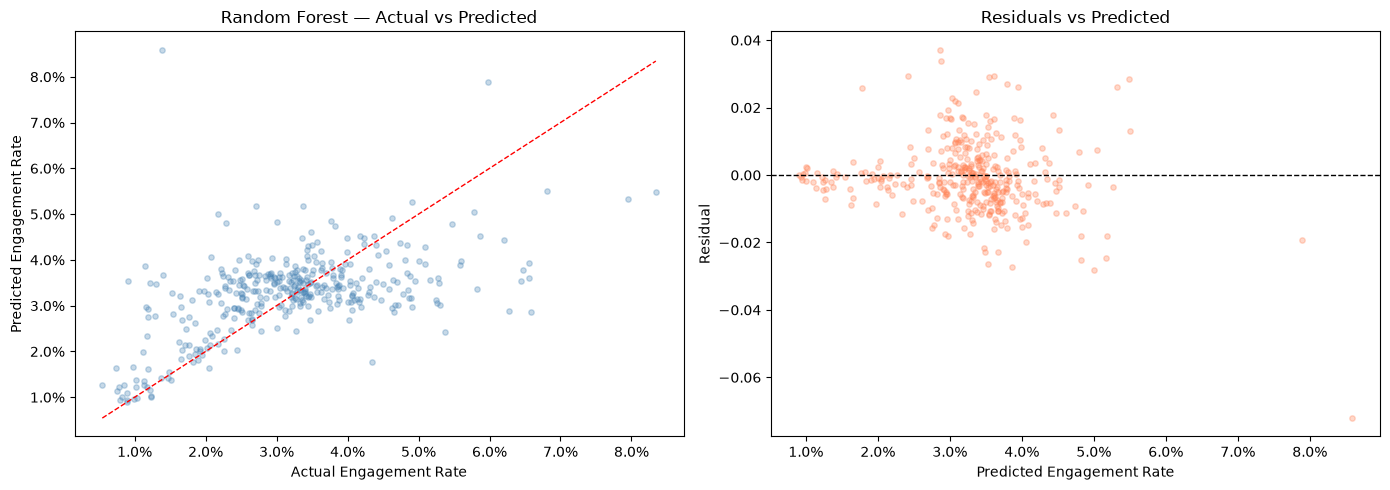

In [242]:
# Check train vs test R² to assess overfitting
rf_train_preds = rf.predict(X_train)
print(f"Train R²: {r2_score(y_train, rf_train_preds):.4f}")
print(f"Test R²:  {r2_score(y_test, rf_preds):.4f}")
print(f"Gap:      {r2_score(y_train, rf_train_preds) - r2_score(y_test, rf_preds):.4f}")

# Also plot actual vs predicted to see where the model struggles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, rf_preds, alpha=0.3, color="steelblue", s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--", linewidth=1)
axes[0].set_title("Random Forest — Actual vs Predicted")
axes[0].set_xlabel("Actual Engagement Rate")
axes[0].set_ylabel("Predicted Engagement Rate")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))

# Residuals
residuals = y_test - rf_preds
axes[1].scatter(rf_preds, residuals, alpha=0.3, color="coral", s=15)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted Engagement Rate")
axes[1].set_ylabel("Residual")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))

plt.tight_layout()
plt.show()

In [243]:
param_grid = {
    "n_estimators": [200],
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [10, 20, 30, 50],
    "max_features": ["sqrt", 0.5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="r2",
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
best_preds = best_rf.predict(X_test)
best_train_preds = best_rf.predict(X_train)

print(f"\nTrain R²: {r2_score(y_train, best_train_preds):.4f}")
print(f"Test R²: {r2_score(y_test, best_preds):.4f}")
print(f"Gap: {r2_score(y_train, best_train_preds) - r2_score(y_test, best_preds):.4f}")
print(f"MAE: {mean_absolute_error(y_test, best_preds):.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV R²: 0.2762

Train R²: 0.4305
Test R²: 0.3839
Gap: 0.0466
MAE: 0.0073


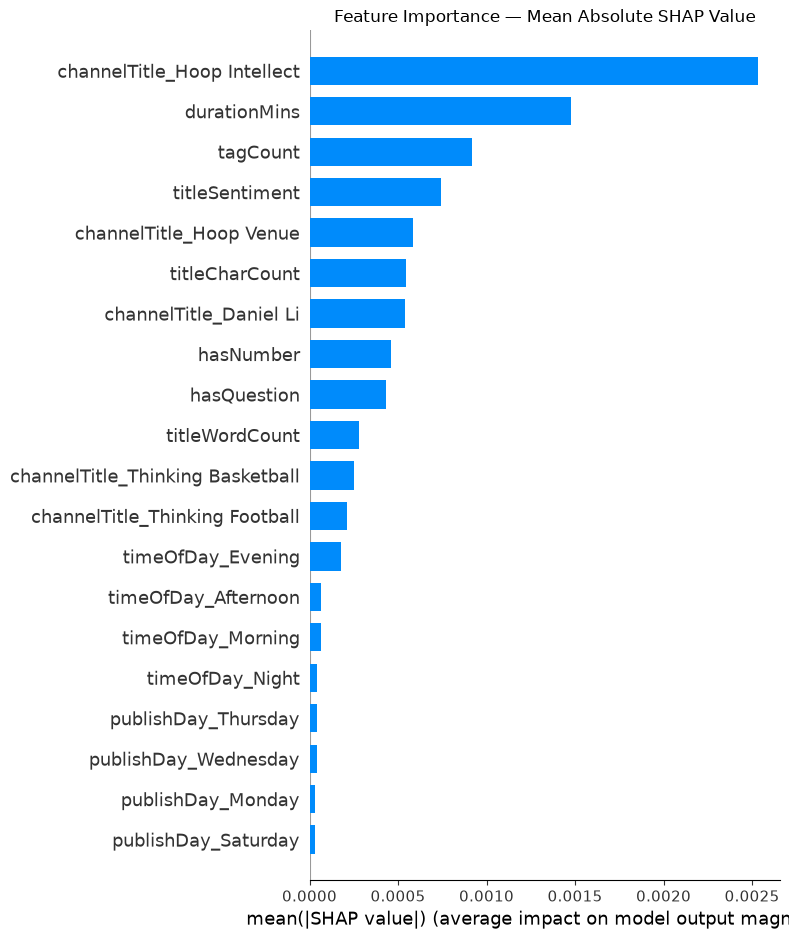

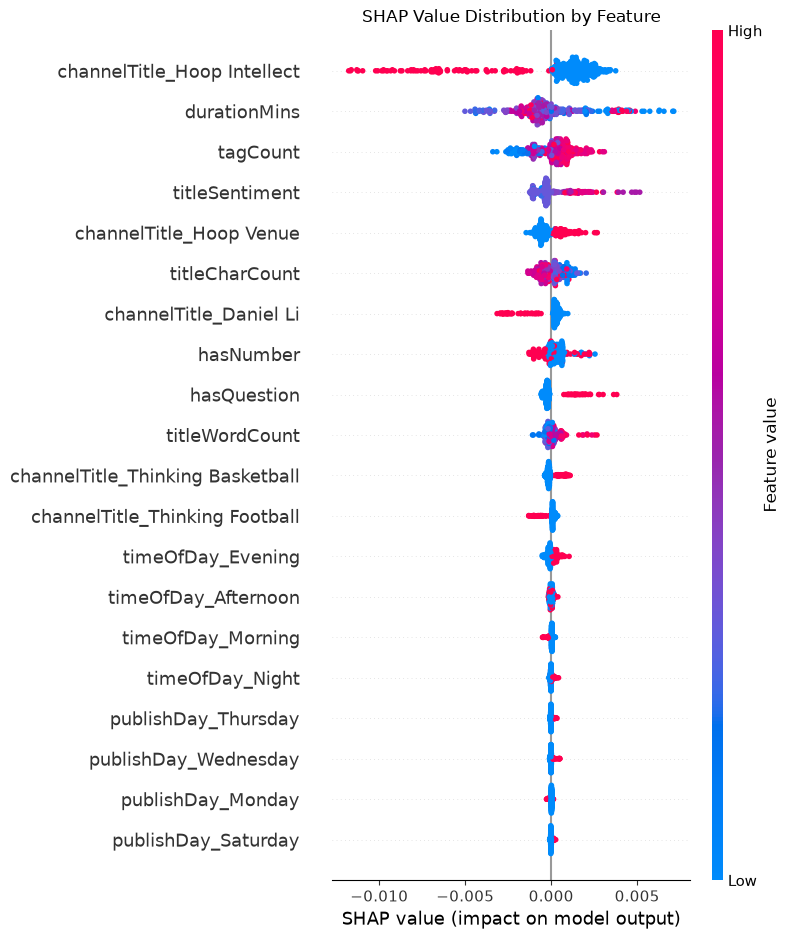

channelTitle_Hoop Intellect         0.00253
durationMins                        0.00148
tagCount                            0.00092
titleSentiment                      0.00074
channelTitle_Hoop Venue             0.00058
titleCharCount                      0.00054
channelTitle_Daniel Li              0.00054
hasNumber                           0.00046
hasQuestion                         0.00043
titleWordCount                      0.00028
channelTitle_Thinking Basketball    0.00025
channelTitle_Thinking Football      0.00021
timeOfDay_Evening                   0.00018
timeOfDay_Afternoon                 0.00007
timeOfDay_Morning                   0.00006
timeOfDay_Night                     0.00004
publishDay_Thursday                 0.00004
publishDay_Wednesday                0.00004
publishDay_Monday                   0.00003
publishDay_Saturday                 0.00003
publishDay_Friday                   0.00003
publishDay_Tuesday                  0.00002
hasVs                           

In [244]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# --- Plot 1: Global feature importance (mean absolute SHAP) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance — Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

# --- Plot 2: SHAP beeswarm — direction and magnitude ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Value Distribution by Feature")
plt.tight_layout()
plt.show()

# --- Top features by mean absolute SHAP for reference ---
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
print(mean_shap.round(5).to_string())

In [245]:
tableau_vids = video_df[['videoId', 'videoTitle', 'channelTitle', 'publishedAt', 'viewCount', 'likeCount', 'commentCount', 'definition', 'timeOfDay', 'durationMins', 'engagementRate', 'tagCount', 'titleWordCount', 'titleCharCount', 'hasQuestion', 'hasNumber', 'hasVs']]

In [246]:
tableau_vids.to_csv('../data/processed/videos_final.csv', index=False)